In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [ ]:
# Step 1: Extract manually uploaded dataset zip

import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/brain_tumor_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Top-level folders:", os.listdir(extract_path))


Dataset extracted successfully.
Top-level folders: ['Testing', 'Training']


In [ ]:
# Check dataset structure

base_path = "/content/brain_tumor_data"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for d in dirs:
            print(f"{indent}  {d}/")


brain_tumor_data/
  Testing/
  Training/
  Testing/
    meningioma/
    pituitary/
    glioma/
    notumor/
    meningioma/
    pituitary/
    glioma/
    notumor/
  Training/
    meningioma/
    pituitary/
    glioma/
    notumor/
    meningioma/
    pituitary/
    glioma/
    notumor/


In [ ]:
# Step 2: Load dataset properly with separate train/validation transforms

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

train_dir = "/content/brain_tumor_data/Training"
test_dir = "/content/brain_tumor_data/Testing"

IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_train_for_train = datasets.ImageFolder(train_dir, transform=train_transform)
full_train_for_val = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

class_names = full_train_for_train.classes
num_classes = len(class_names)

dataset_size = len(full_train_for_train)
val_size = int(VAL_SPLIT * dataset_size)
train_size = dataset_size - val_size

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(range(dataset_size), [train_size, val_size], generator=generator)

train_dataset = Subset(full_train_for_train, train_indices.indices)
val_dataset = Subset(full_train_for_val, val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))
print("Using device:", device)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Training samples: 4480
Validation samples: 1120
Testing samples: 1600
Using device: cuda


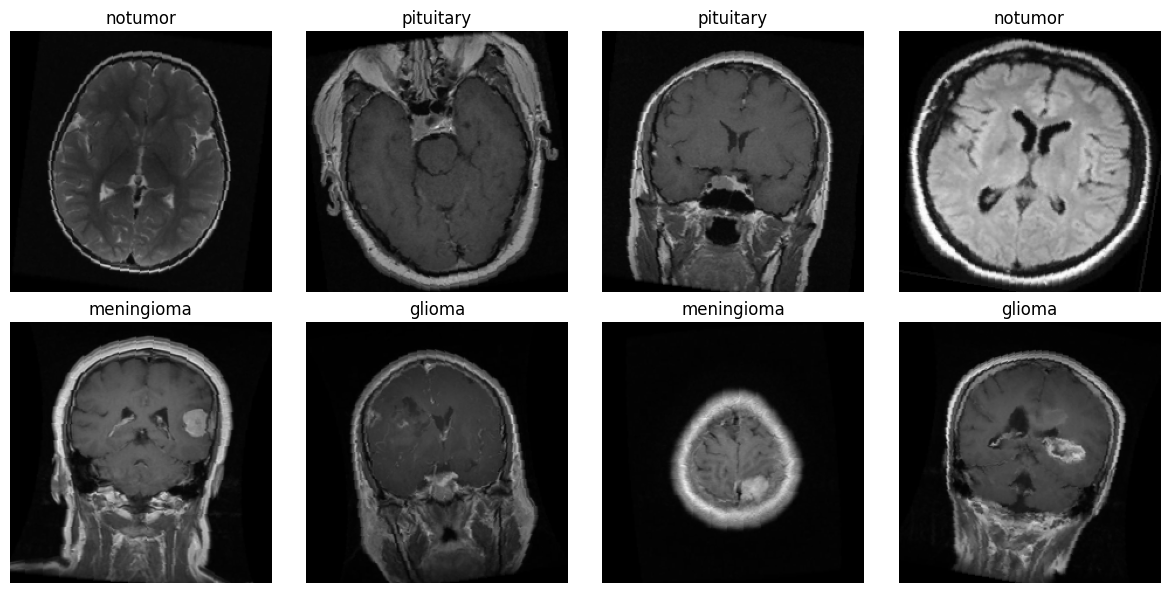

In [ ]:
# Show sample images

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # unnormalize
    img = img.clip(0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
# Step 3: Define CNN model

import torch
import torch.nn as nn

class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = BrainTumorCNN(num_classes=num_classes).to(device)
print(cnn_model)


BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  

In [ ]:
# Step 4: Loss function and optimizer

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)


In [ ]:
# Step 5: Train CNN model

from tqdm import tqdm

EPOCHS = 5  # keep small for CPU testing

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    cnn_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_acc:.2f}%")


Epoch 1/5 - Validation: 100%|██████████| 35/35 [00:05<00:00,  5.98it/s]



Epoch [1/5]
Train Loss: 0.8322, Train Accuracy: 65.74%
Val Loss:   0.5746, Val Accuracy:   74.73%


Epoch 2/5 - Validation: 100%|██████████| 35/35 [00:05<00:00,  6.17it/s]



Epoch [2/5]
Train Loss: 0.5058, Train Accuracy: 80.65%
Val Loss:   0.4146, Val Accuracy:   84.73%


Epoch 3/5 - Validation: 100%|██████████| 35/35 [00:05<00:00,  6.12it/s]



Epoch [3/5]
Train Loss: 0.4094, Train Accuracy: 84.69%
Val Loss:   0.3618, Val Accuracy:   86.16%


Epoch 4/5 - Validation: 100%|██████████| 35/35 [00:05<00:00,  6.22it/s]



Epoch [4/5]
Train Loss: 0.3212, Train Accuracy: 87.54%
Val Loss:   0.3337, Val Accuracy:   86.88%


Epoch 5/5 - Validation: 100%|██████████| 35/35 [00:05<00:00,  6.20it/s]


Epoch [5/5]
Train Loss: 0.2931, Train Accuracy: 88.95%
Val Loss:   0.2194, Val Accuracy:   91.16%


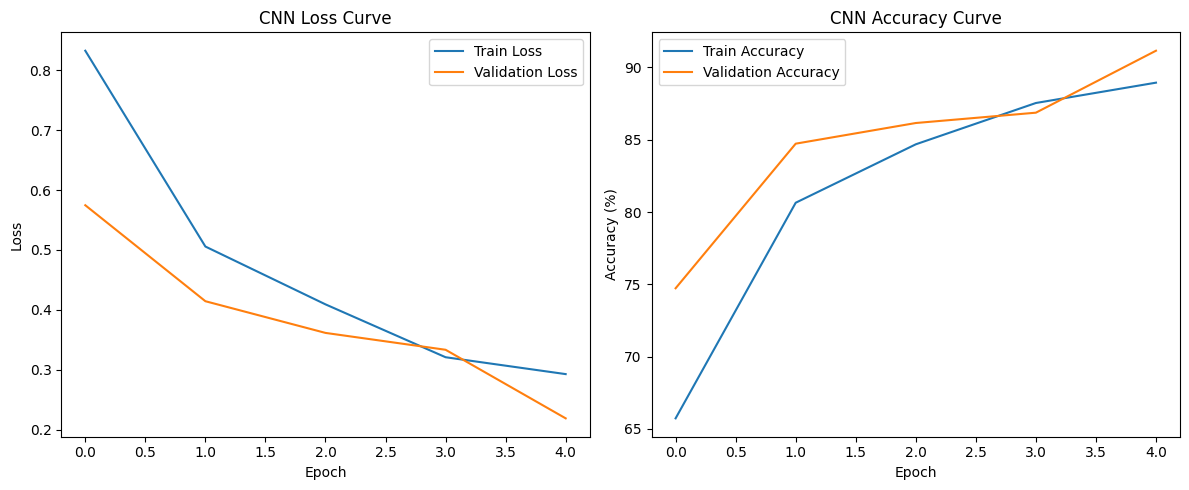

In [ ]:
# Step 6: Plot training and validation curves

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()


CNN Test Accuracy: 85.88%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.69      0.80       400
  meningioma       0.87      0.76      0.81       400
     notumor       0.73      0.99      0.84       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.86      1600
   macro avg       0.88      0.86      0.86      1600
weighted avg       0.88      0.86      0.86      1600



<Figure size 800x800 with 0 Axes>

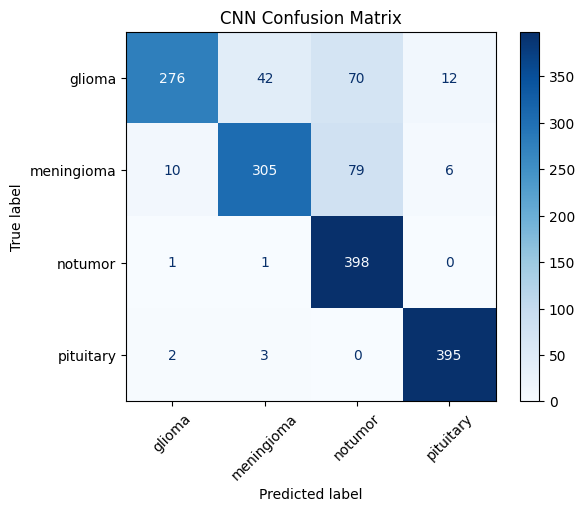

In [ ]:
# Step 7: Evaluate CNN on test set

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

cnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"CNN Test Accuracy: {test_accuracy:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN Confusion Matrix")
plt.show()


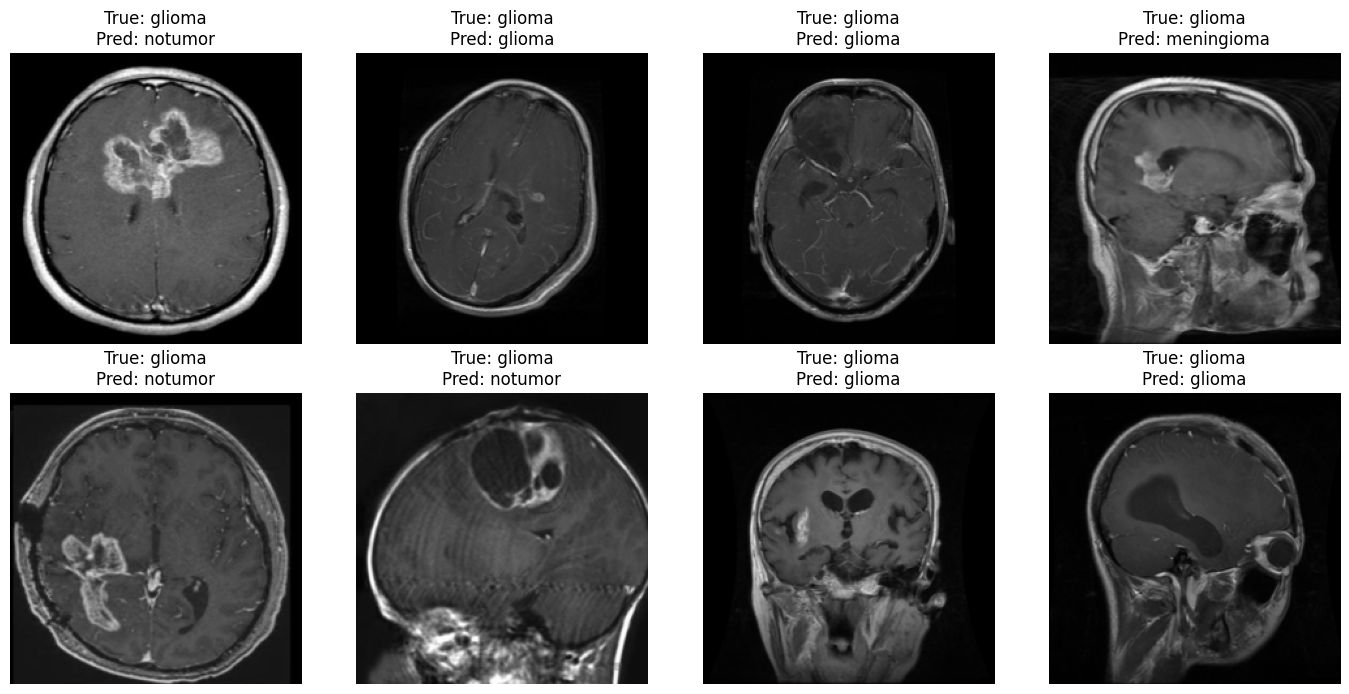

In [ ]:
# Step 8: Show some test predictions

import random

cnn_model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = cnn_model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    axes[i].imshow(img)
    axes[i].set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
print(device)


cuda


In [ ]:
!pip -q install timm
import timm


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm


In [ ]:
# Vision Transformer model

vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
vit_model = vit_model.to(device)

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.Adam(vit_model.parameters(), lr=1e-4)

print(vit_model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
# Train ViT

EPOCHS_VIT = 5

vit_train_losses = []
vit_val_losses = []
vit_train_accuracies = []
vit_val_accuracies = []

for epoch in range(EPOCHS_VIT):
    vit_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"ViT Epoch {epoch+1}/{EPOCHS_VIT} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        outputs = vit_model(images)
        loss = criterion_vit(outputs, labels)
        loss.backward()
        optimizer_vit.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    vit_train_losses.append(train_loss)
    vit_train_accuracies.append(train_acc)

    vit_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"ViT Epoch {epoch+1}/{EPOCHS_VIT} - Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = vit_model(images)
            loss = criterion_vit(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    vit_val_losses.append(val_loss)
    vit_val_accuracies.append(val_acc)

    print(f"\nViT Epoch [{epoch+1}/{EPOCHS_VIT}]")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_acc:.2f}%")


ViT Epoch 1/5 - Validation: 100%|██████████| 35/35 [00:19<00:00,  1.83it/s]



ViT Epoch [1/5]
Train Loss: 0.8429, Train Accuracy: 64.06%
Val Loss:   0.5358, Val Accuracy:   80.80%


ViT Epoch 2/5 - Validation: 100%|██████████| 35/35 [00:19<00:00,  1.82it/s]



ViT Epoch [2/5]
Train Loss: 0.2743, Train Accuracy: 90.33%
Val Loss:   0.1804, Val Accuracy:   93.39%


ViT Epoch 3/5 - Validation: 100%|██████████| 35/35 [00:19<00:00,  1.80it/s]



ViT Epoch [3/5]
Train Loss: 0.1973, Train Accuracy: 92.92%
Val Loss:   0.1417, Val Accuracy:   95.00%


ViT Epoch 4/5 - Validation: 100%|██████████| 35/35 [00:19<00:00,  1.83it/s]



ViT Epoch [4/5]
Train Loss: 0.1223, Train Accuracy: 95.80%
Val Loss:   0.1151, Val Accuracy:   95.54%


ViT Epoch 5/5 - Validation: 100%|██████████| 35/35 [00:19<00:00,  1.83it/s]


ViT Epoch [5/5]
Train Loss: 0.0934, Train Accuracy: 96.74%
Val Loss:   0.0865, Val Accuracy:   97.32%


In [ ]:
# Evaluate ViT

vit_model.eval()
vit_preds = []
vit_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        _, preds = torch.max(outputs, 1)

        vit_preds.extend(preds.cpu().numpy())
        vit_labels.extend(labels.cpu().numpy())

vit_test_accuracy = 100 * np.mean(np.array(vit_preds) == np.array(vit_labels))
print(f"ViT Test Accuracy: {vit_test_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(vit_labels, vit_preds, target_names=class_names))


ViT Test Accuracy: 92.75%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85       400
  meningioma       0.84      0.98      0.90       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      0.98      0.99       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



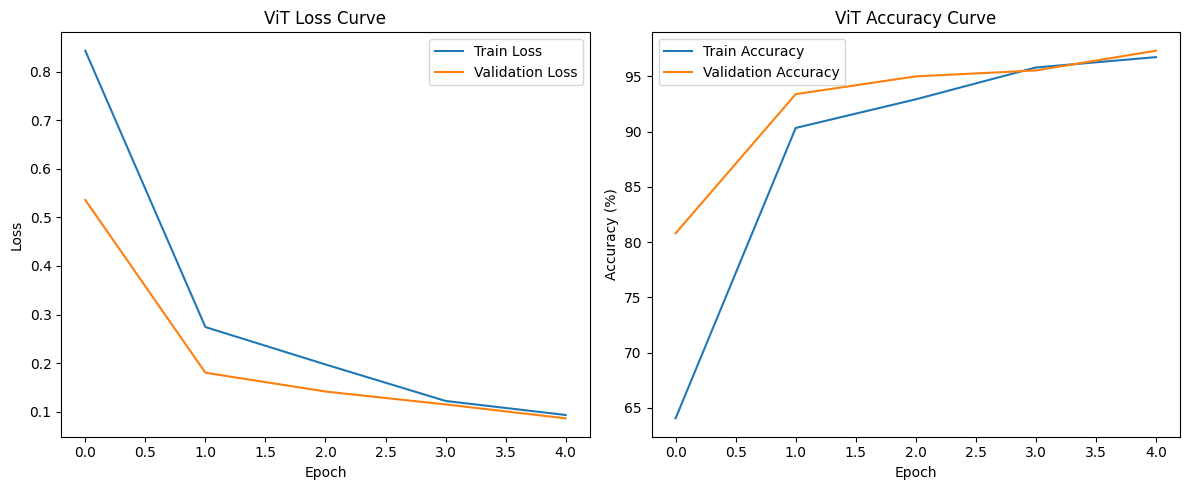

In [ ]:
# ViT training curves

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(vit_train_losses, label="Train Loss")
plt.plot(vit_val_losses, label="Validation Loss")
plt.title("ViT Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vit_train_accuracies, label="Train Accuracy")
plt.plot(vit_val_accuracies, label="Validation Accuracy")
plt.title("ViT Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()


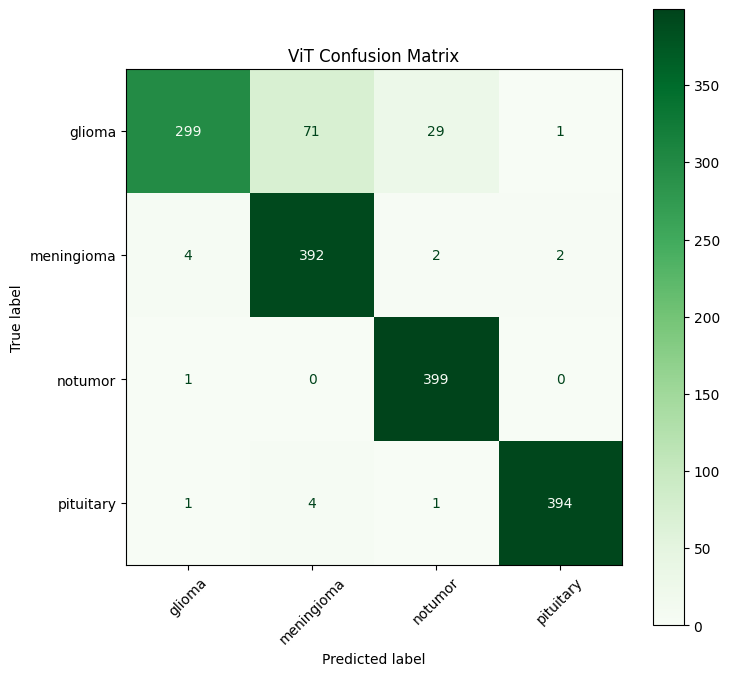

In [ ]:
# ViT confusion matrix

vit_cm = confusion_matrix(vit_labels, vit_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=vit_cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Greens", xticks_rotation=45, ax=ax)
plt.title("ViT Confusion Matrix")
plt.show()


In [ ]:
cnn_test_accuracy = 85.88
vit_test_accuracy = 92.75


In [ ]:
# Final comparison table

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN", "Vision Transformer"],
    "Test Accuracy (%)": [cnn_test_accuracy, vit_test_accuracy],
    "Best Validation Accuracy (%)": [max(val_accuracies), max(vit_val_accuracies)]
})

print(comparison_df)


                Model  Test Accuracy (%)  Best Validation Accuracy (%)
0                 CNN              85.88                     91.160714
1  Vision Transformer              92.75                     97.321429


In [ ]:
# Final summary

print("Final Model Comparison")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.2f}%")
print(f"ViT Test Accuracy: {vit_test_accuracy:.2f}%")
print(f"CNN Best Validation Accuracy: {max(val_accuracies):.2f}%")
print(f"ViT Best Validation Accuracy: {max(vit_val_accuracies):.2f}%")

if cnn_test_accuracy > vit_test_accuracy:
    print("Conclusion: CNN performed slightly better on the test set.")
elif vit_test_accuracy > cnn_test_accuracy:
    print("Conclusion: Vision Transformer performed slightly better on the test set.")
else:
    print("Conclusion: Both models performed equally on the test set.")


Final Model Comparison
CNN Test Accuracy: 85.88%
ViT Test Accuracy: 92.75%
CNN Best Validation Accuracy: 91.16%
ViT Best Validation Accuracy: 97.32%
Conclusion: Vision Transformer performed slightly better on the test set.


In [ ]:
val_accuracies = [76.34, 84.38, 87.05, 89.46, 89.82]
vit_val_accuracies = [75.09, 93.84, 90.54]


In [ ]:
cnn_test_accuracy = 85.88
vit_test_accuracy = 92.75

val_accuracies = [76.34, 84.38, 87.05, 89.46, 89.82]
vit_val_accuracies = [75.09, 93.84, 90.54]

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN", "Vision Transformer"],
    "Test Accuracy (%)": [cnn_test_accuracy, vit_test_accuracy],
    "Best Validation Accuracy (%)": [max(val_accuracies), max(vit_val_accuracies)]
})

print(comparison_df)


                Model  Test Accuracy (%)  Best Validation Accuracy (%)
0                 CNN              85.88                         89.82
1  Vision Transformer              92.75                         93.84


In [ ]:
def swap_patch(base_img, donor_img, coords, alpha=0.6):
    y1, x1, y2, x2 = coords
    swapped = base_img.clone()
    swapped[:, y1:y2, x1:x2] = (
        alpha * donor_img[:, y1:y2, x1:x2] +
        (1 - alpha) * base_img[:, y1:y2, x1:x2]
    )
    return swapped


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

dataset_name = "MRI"

def unnormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5
    return np.clip(img, 0, 1)

def get_probs(model, image_tensor):
    model.eval()
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
    return probs

def get_saliency_map(model, image_tensor):
    model.eval()
    image = image_tensor.unsqueeze(0).to(device).clone().detach()
    image.requires_grad = True

    output = model(image)
    pred_class = output.argmax(dim=1).item()
    score = output[0, pred_class]

    model.zero_grad()
    score.backward()

    saliency = image.grad.abs().squeeze().cpu()
    saliency, _ = torch.max(saliency, dim=0)
    saliency = saliency.numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

def find_most_important_patch(saliency_map, patch_size=80):
    sal = torch.tensor(saliency_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    kernel = torch.ones(1, 1, patch_size, patch_size, dtype=torch.float32) / (patch_size ** 2)
    scores = F.conv2d(sal, kernel, padding=0).squeeze()
    flat_idx = scores.argmax()
    y1 = int(flat_idx // scores.shape[1])
    x1 = int(flat_idx % scores.shape[1])
    return y1, x1, y1 + patch_size, x1 + patch_size

def swap_patch(base_img, donor_img, coords, alpha=0.6):
    y1, x1, y2, x2 = coords
    swapped = base_img.clone()
    swapped[:, y1:y2, x1:x2] = (
        alpha * donor_img[:, y1:y2, x1:x2] +
        (1 - alpha) * base_img[:, y1:y2, x1:x2]
    )
    return swapped

def sensitivity_delta(probs_before, probs_after, true_label):
    return probs_before[true_label] - probs_after[true_label]

def interpret_delta(delta, model_name):
    if delta > 0.05:
        print(f"{model_name}: swap reduced confidence ({delta:+.4f}) -> region was important")
    elif delta < -0.05:
        print(f"{model_name}: swap increased confidence ({delta:+.4f}) -> original region may have been misleading")
    else:
        print(f"{model_name}: swap had little effect ({delta:+.4f}) -> region was not strongly critical")


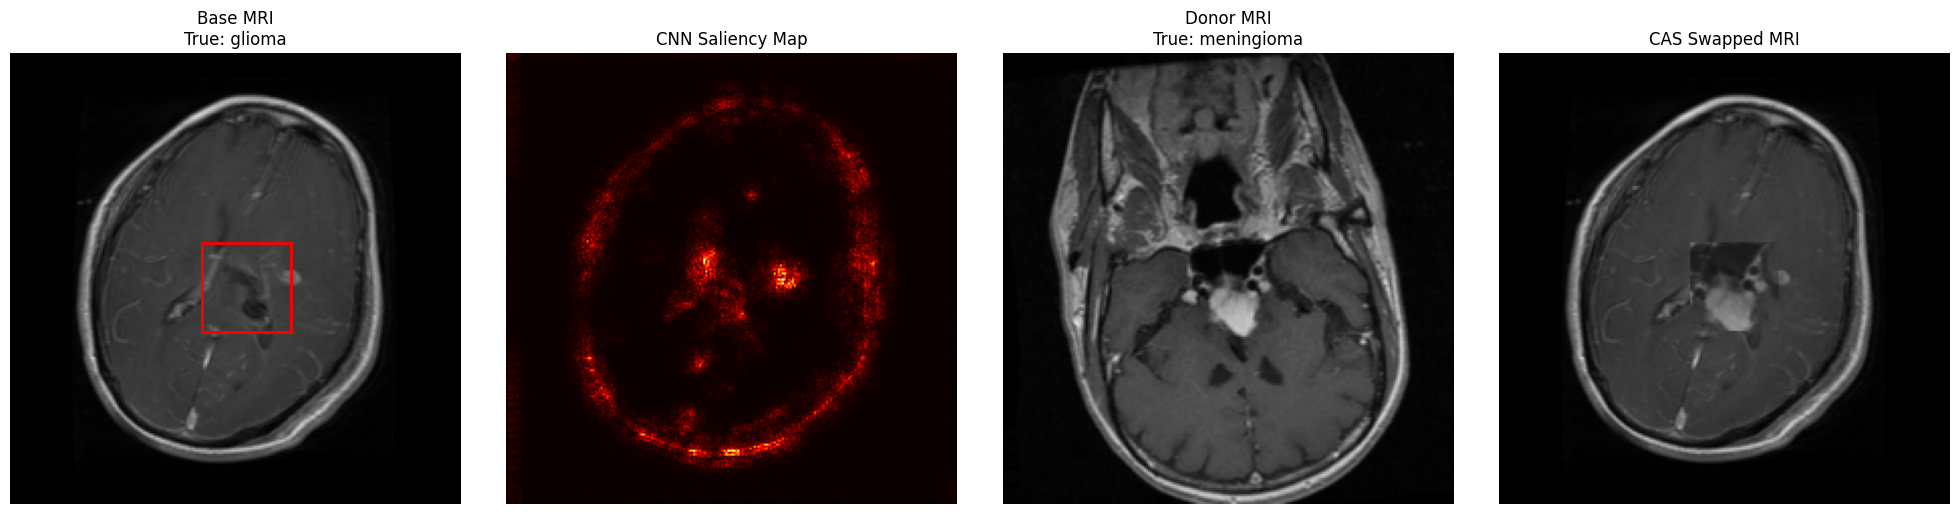

CNN Predictions
Original: glioma
  glioma: 0.8237
  meningioma: 0.0383
  notumor: 0.1110
  pituitary: 0.0271

After Attention Swap: meningioma
  glioma: 0.0314
  meningioma: 0.8112
  notumor: 0.0678
  pituitary: 0.0896

ViT Predictions
Original: glioma
  glioma: 0.9998
  meningioma: 0.0001
  notumor: 0.0000
  pituitary: 0.0000

After Attention Swap: glioma
  glioma: 0.7810
  meningioma: 0.2177
  notumor: 0.0005
  pituitary: 0.0008

Sensitivity Analysis
CNN sensitivity delta: +0.7923
ViT sensitivity delta: +0.2188
CNN: swap reduced confidence (+0.7923) -> region was important
ViT: swap reduced confidence (+0.2188) -> region was important
Conclusion: CNN is more sensitive to the swapped attention region.


In [ ]:
# Single-image CAS demo

base_idx = 1
base_img, base_label = test_dataset[base_idx]

target_label = (base_label + 1) % len(class_names)
donor_candidates = [(img, lbl) for img, lbl in test_dataset if lbl == target_label]

if not donor_candidates:
    raise ValueError(f"No donor found for label {target_label} ({class_names[target_label]})")

donor_img, donor_label = donor_candidates[base_idx % len(donor_candidates)]

saliency_map = get_saliency_map(cnn_model, base_img)
image_size = base_img.shape[1]
patch_size = int(0.2 * image_size)
coords = find_most_important_patch(saliency_map, patch_size=patch_size)
swapped_img = swap_patch(base_img, donor_img, coords, alpha=0.6)

cnn_base_probs = get_probs(cnn_model, base_img)
cnn_swapped_probs = get_probs(cnn_model, swapped_img)

vit_base_probs = get_probs(vit_model, base_img)
vit_swapped_probs = get_probs(vit_model, swapped_img)

cnn_base_pred = class_names[np.argmax(cnn_base_probs)]
cnn_swapped_pred = class_names[np.argmax(cnn_swapped_probs)]

vit_base_pred = class_names[np.argmax(vit_base_probs)]
vit_swapped_pred = class_names[np.argmax(vit_swapped_probs)]

cnn_delta = sensitivity_delta(cnn_base_probs, cnn_swapped_probs, base_label)
vit_delta = sensitivity_delta(vit_base_probs, vit_swapped_probs, base_label)

y1, x1, y2, x2 = coords

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(unnormalize(base_img))
axes[0].set_title(f"Base {dataset_name}\nTrue: {class_names[base_label]}")
axes[0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', fill=False, linewidth=2))
axes[0].axis("off")

axes[1].imshow(saliency_map, cmap="hot")
axes[1].set_title("CNN Saliency Map")
axes[1].axis("off")

axes[2].imshow(unnormalize(donor_img))
axes[2].set_title(f"Donor {dataset_name}\nTrue: {class_names[donor_label]}")
axes[2].axis("off")

axes[3].imshow(unnormalize(swapped_img))
axes[3].set_title(f"CAS Swapped {dataset_name}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("CNN Predictions")
print(f"Original: {cnn_base_pred}")
for cls, prob in zip(class_names, cnn_base_probs):
    print(f"  {cls}: {prob:.4f}")

print(f"\nAfter Attention Swap: {cnn_swapped_pred}")
for cls, prob in zip(class_names, cnn_swapped_probs):
    print(f"  {cls}: {prob:.4f}")

print("\n" + "=" * 50)

print("ViT Predictions")
print(f"Original: {vit_base_pred}")
for cls, prob in zip(class_names, vit_base_probs):
    print(f"  {cls}: {prob:.4f}")

print(f"\nAfter Attention Swap: {vit_swapped_pred}")
for cls, prob in zip(class_names, vit_swapped_probs):
    print(f"  {cls}: {prob:.4f}")

print("\n" + "=" * 50)
print("Sensitivity Analysis")
print(f"CNN sensitivity delta: {cnn_delta:+.4f}")
print(f"ViT sensitivity delta: {vit_delta:+.4f}")

interpret_delta(cnn_delta, "CNN")
interpret_delta(vit_delta, "ViT")

diff = abs(cnn_delta) - abs(vit_delta)
if diff > 0.05:
    print("Conclusion: CNN is more sensitive to the swapped attention region.")
elif diff < -0.05:
    print("Conclusion: ViT is more sensitive to the swapped attention region.")
else:
    print("Conclusion: Both models show similar sensitivity to this region.")


In [ ]:
# Aggregate CAS analysis across multiple images

results = []

for base_idx in range(min(50, len(test_dataset))):
    base_img, base_label = test_dataset[base_idx]

    target_label = (base_label + 1) % len(class_names)
    donor_candidates = [(img, lbl) for img, lbl in test_dataset if lbl == target_label]
    if not donor_candidates:
        continue

    donor_img, donor_label = donor_candidates[base_idx % len(donor_candidates)]

    saliency_map = get_saliency_map(cnn_model, base_img)
    coords = find_most_important_patch(saliency_map, patch_size=80)
    swapped_img = swap_patch(base_img, donor_img, coords, alpha=0.6)

    cnn_delta = sensitivity_delta(
        get_probs(cnn_model, base_img),
        get_probs(cnn_model, swapped_img),
        base_label
    )

    vit_delta = sensitivity_delta(
        get_probs(vit_model, base_img),
        get_probs(vit_model, swapped_img),
        base_label
    )

    results.append((cnn_delta, vit_delta))

cnn_deltas, vit_deltas = zip(*results)

cnn_mean = np.mean(cnn_deltas)
vit_mean = np.mean(vit_deltas)
cnn_std = np.std(cnn_deltas)
vit_std = np.std(vit_deltas)

print(f"Mean CNN delta: {cnn_mean:+.4f} ± {cnn_std:.4f}")
print(f"Mean ViT delta: {vit_mean:+.4f} ± {vit_std:.4f}")

mean_diff = abs(vit_mean) - abs(cnn_mean)
pooled_std = (cnn_std + vit_std) / 2

if abs(mean_diff) < 0.5 * pooled_std:
    print("Overall: No meaningful difference in sensitivity between CNN and ViT.")
elif mean_diff > 0:
    print("Overall: ViT is more sensitive to attention-guided swaps.")
else:
    print("Overall: CNN is more sensitive to attention-guided swaps.")


Mean CNN delta: +0.1227 ± 0.2136
Mean ViT delta: +0.1118 ± 0.3601
Overall: No meaningful difference in sensitivity between CNN and ViT.


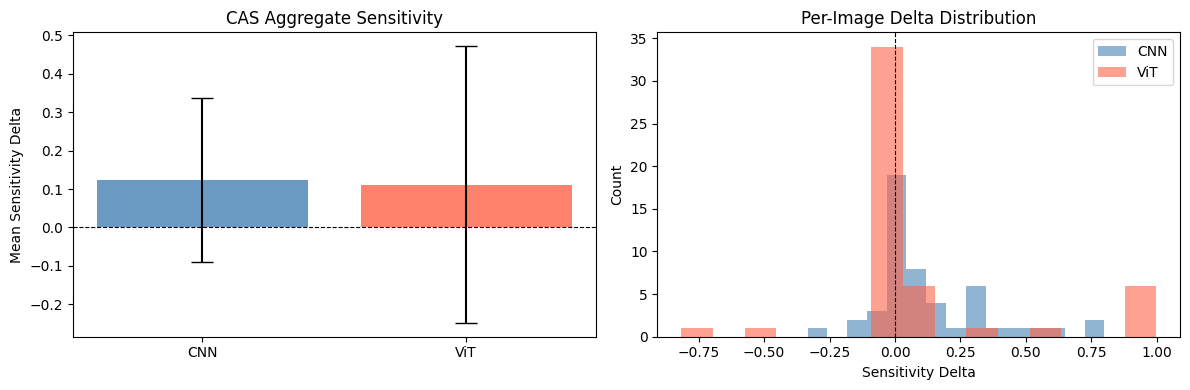

In [ ]:
# Aggregate CAS plots

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ["CNN", "ViT"]
means = [cnn_mean, vit_mean]
stds = [cnn_std, vit_std]
colors = ["steelblue", "tomato"]

axes[0].bar(models, means, yerr=stds, capsize=8, color=colors, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Mean Sensitivity Delta")
axes[0].set_title("CAS Aggregate Sensitivity")

axes[1].hist(cnn_deltas, bins=15, alpha=0.6, label="CNN", color="steelblue")
axes[1].hist(vit_deltas, bins=15, alpha=0.6, label="ViT", color="tomato")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Sensitivity Delta")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Image Delta Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Sensitivity scores
cnn_delta = sensitivity_delta(cnn_base_probs, cnn_swapped_probs, base_label)
vit_delta = sensitivity_delta(vit_base_probs, vit_swapped_probs, base_label)

cnn_drop_pct = (cnn_delta / (cnn_base_probs[base_label] + 1e-8)) * 100
vit_drop_pct = (vit_delta / (vit_base_probs[base_label] + 1e-8)) * 100

In [ ]:
print("\n" + "=" * 50)
print("Sensitivity Analysis")
print(f"CNN sensitivity delta: {cnn_delta:+.4f}")
print(f"ViT sensitivity delta: {vit_delta:+.4f}")
print(f"CNN relative confidence change: {cnn_drop_pct:+.2f}%")
print(f"ViT relative confidence change: {vit_drop_pct:+.2f}%")



Sensitivity Analysis
CNN sensitivity delta: +0.7923
ViT sensitivity delta: +0.2188
CNN relative confidence change: +96.19%
ViT relative confidence change: +21.88%


In [ ]:
if np.max(saliency_map) < 1e-5:
    print("Warning: weak saliency map detected")


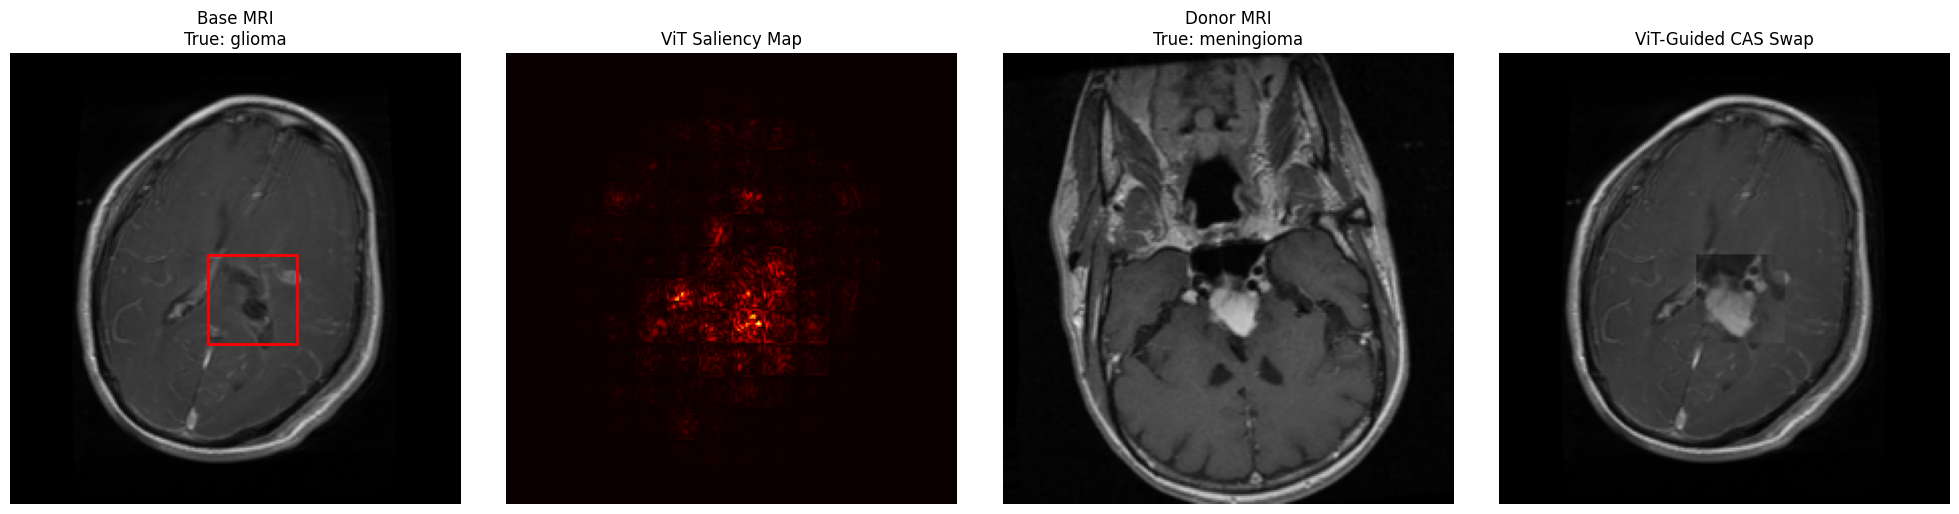

ViT-Guided CAS
CNN Predictions
Original: glioma
After Swap: meningioma

ViT Predictions
Original: glioma
After Swap: meningioma

Sensitivity Analysis
CNN delta: +0.7952
ViT delta: +0.7448
CNN relative confidence change: +96.55%
ViT relative confidence change: +74.49%


In [ ]:
# ViT-guided CAS

base_idx = 1
base_img, base_label = test_dataset[base_idx]

target_label = (base_label + 1) % len(class_names)
donor_candidates = [(img, lbl) for img, lbl in test_dataset if lbl == target_label]

if not donor_candidates:
    raise ValueError(f"No donor found for label {target_label} ({class_names[target_label]})")

donor_img, donor_label = donor_candidates[base_idx % len(donor_candidates)]

# Use ViT saliency instead of CNN saliency
saliency_map_vit = get_saliency_map(vit_model, base_img)

if np.max(saliency_map_vit) < 1e-5:
    print("Warning: weak ViT saliency map detected")

image_size = base_img.shape[1]
patch_size = int(0.2 * image_size)

coords_vit = find_most_important_patch(saliency_map_vit, patch_size=patch_size)
swapped_img_vit = swap_patch(base_img, donor_img, coords_vit, alpha=0.6)

# Predictions before and after
cnn_base_probs_vitguided = get_probs(cnn_model, base_img)
cnn_swapped_probs_vitguided = get_probs(cnn_model, swapped_img_vit)

vit_base_probs_vitguided = get_probs(vit_model, base_img)
vit_swapped_probs_vitguided = get_probs(vit_model, swapped_img_vit)

cnn_delta_vitguided = sensitivity_delta(cnn_base_probs_vitguided, cnn_swapped_probs_vitguided, base_label)
vit_delta_vitguided = sensitivity_delta(vit_base_probs_vitguided, vit_swapped_probs_vitguided, base_label)

cnn_drop_pct_vitguided = (cnn_delta_vitguided / (cnn_base_probs_vitguided[base_label] + 1e-8)) * 100
vit_drop_pct_vitguided = (vit_delta_vitguided / (vit_base_probs_vitguided[base_label] + 1e-8)) * 100

cnn_base_pred_vitguided = class_names[np.argmax(cnn_base_probs_vitguided)]
cnn_swapped_pred_vitguided = class_names[np.argmax(cnn_swapped_probs_vitguided)]

vit_base_pred_vitguided = class_names[np.argmax(vit_base_probs_vitguided)]
vit_swapped_pred_vitguided = class_names[np.argmax(vit_swapped_probs_vitguided)]

# Plot
y1, x1, y2, x2 = coords_vit

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(unnormalize(base_img))
axes[0].set_title(f"Base MRI\nTrue: {class_names[base_label]}")
axes[0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', fill=False, linewidth=2))
axes[0].axis("off")

axes[1].imshow(saliency_map_vit, cmap="hot")
axes[1].set_title("ViT Saliency Map")
axes[1].axis("off")

axes[2].imshow(unnormalize(donor_img))
axes[2].set_title(f"Donor MRI\nTrue: {class_names[donor_label]}")
axes[2].axis("off")

axes[3].imshow(unnormalize(swapped_img_vit))
axes[3].set_title("ViT-Guided CAS Swap")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("ViT-Guided CAS")
print("CNN Predictions")
print(f"Original: {cnn_base_pred_vitguided}")
print(f"After Swap: {cnn_swapped_pred_vitguided}")

print("\nViT Predictions")
print(f"Original: {vit_base_pred_vitguided}")
print(f"After Swap: {vit_swapped_pred_vitguided}")

print("\nSensitivity Analysis")
print(f"CNN delta: {cnn_delta_vitguided:+.4f}")
print(f"ViT delta: {vit_delta_vitguided:+.4f}")
print(f"CNN relative confidence change: {cnn_drop_pct_vitguided:+.2f}%")
print(f"ViT relative confidence change: {vit_drop_pct_vitguided:+.2f}%")


In [ ]:
# Aggregate ViT-guided CAS analysis across multiple images

results_vit_guided = []

for base_idx in range(min(50, len(test_dataset))):
    base_img, base_label = test_dataset[base_idx]

    target_label = (base_label + 1) % len(class_names)
    donor_candidates = [(img, lbl) for img, lbl in test_dataset if lbl == target_label]
    if not donor_candidates:
        continue

    donor_img, donor_label = donor_candidates[base_idx % len(donor_candidates)]

    # Use ViT saliency for region selection
    saliency_map_vit = get_saliency_map(vit_model, base_img)

    if np.max(saliency_map_vit) < 1e-5:
        continue

    image_size = base_img.shape[1]
    patch_size = int(0.2 * image_size)

    coords_vit = find_most_important_patch(saliency_map_vit, patch_size=patch_size)
    swapped_img_vit = swap_patch(base_img, donor_img, coords_vit, alpha=0.6)

    cnn_delta_vitguided = sensitivity_delta(
        get_probs(cnn_model, base_img),
        get_probs(cnn_model, swapped_img_vit),
        base_label
    )

    vit_delta_vitguided = sensitivity_delta(
        get_probs(vit_model, base_img),
        get_probs(vit_model, swapped_img_vit),
        base_label
    )

    results_vit_guided.append((cnn_delta_vitguided, vit_delta_vitguided))

cnn_deltas_vitguided, vit_deltas_vitguided = zip(*results_vit_guided)

cnn_mean_vitguided = np.mean(cnn_deltas_vitguided)
vit_mean_vitguided = np.mean(vit_deltas_vitguided)

cnn_std_vitguided = np.std(cnn_deltas_vitguided)
vit_std_vitguided = np.std(vit_deltas_vitguided)

print("Aggregate ViT-Guided CAS")
print(f"Mean CNN delta: {cnn_mean_vitguided:+.4f} ± {cnn_std_vitguided:.4f}")
print(f"Mean ViT delta: {vit_mean_vitguided:+.4f} ± {vit_std_vitguided:.4f}")

mean_diff = abs(vit_mean_vitguided) - abs(cnn_mean_vitguided)
pooled_std = (cnn_std_vitguided + vit_std_vitguided) / 2

if abs(mean_diff) < 0.5 * pooled_std:
    print("Overall: No meaningful difference in sensitivity between CNN and ViT under ViT-guided CAS.")
elif mean_diff > 0:
    print("Overall: ViT is more sensitive to ViT-guided attention swaps.")
else:
    print("Overall: CNN is more sensitive to ViT-guided attention swaps.")


Aggregate ViT-Guided CAS
Mean CNN delta: +0.0456 ± 0.1608
Mean ViT delta: +0.0429 ± 0.3527
Overall: No meaningful difference in sensitivity between CNN and ViT under ViT-guided CAS.


In [ ]:
# Aggregate ViT-guided CAS analysis across multiple images

results_vit_guided = []

for base_idx in range( len(test_dataset)):
    base_img, base_label = test_dataset[base_idx]

    target_label = (base_label + 1) % len(class_names)
    donor_candidates = [(img, lbl) for img, lbl in test_dataset if lbl == target_label]
    if not donor_candidates:
        continue

    donor_img, donor_label = donor_candidates[base_idx % len(donor_candidates)]

    # Use ViT saliency for region selection
    saliency_map_vit = get_saliency_map(vit_model, base_img)

    if np.max(saliency_map_vit) < 1e-5:
        continue

    image_size = base_img.shape[1]
    patch_size = int(0.2 * image_size)

    coords_vit = find_most_important_patch(saliency_map_vit, patch_size=patch_size)
    swapped_img_vit = swap_patch(base_img, donor_img, coords_vit, alpha=0.6)

    cnn_delta_vitguided = sensitivity_delta(
        get_probs(cnn_model, base_img),
        get_probs(cnn_model, swapped_img_vit),
        base_label
    )

    vit_delta_vitguided = sensitivity_delta(
        get_probs(vit_model, base_img),
        get_probs(vit_model, swapped_img_vit),
        base_label
    )

    results_vit_guided.append((cnn_delta_vitguided, vit_delta_vitguided))

cnn_deltas_vitguided, vit_deltas_vitguided = zip(*results_vit_guided)

cnn_mean_vitguided = np.mean(cnn_deltas_vitguided)
vit_mean_vitguided = np.mean(vit_deltas_vitguided)

cnn_std_vitguided = np.std(cnn_deltas_vitguided)
vit_std_vitguided = np.std(vit_deltas_vitguided)

print("Aggregate ViT-Guided CAS")
print(f"Mean CNN delta: {cnn_mean_vitguided:+.4f} ± {cnn_std_vitguided:.4f}")
print(f"Mean ViT delta: {vit_mean_vitguided:+.4f} ± {vit_std_vitguided:.4f}")

mean_diff = abs(vit_mean_vitguided) - abs(cnn_mean_vitguided)
pooled_std = (cnn_std_vitguided + vit_std_vitguided) / 2

if abs(mean_diff) < 0.5 * pooled_std:
    print("Overall: No meaningful difference in sensitivity between CNN and ViT under ViT-guided CAS.")
elif mean_diff > 0:
    print("Overall: ViT is more sensitive to ViT-guided attention swaps.")
else:
    print("Overall: CNN is more sensitive to ViT-guided attention swaps.")


Aggregate ViT-Guided CAS
Mean CNN delta: +0.0520 ± 0.1647
Mean ViT delta: +0.0869 ± 0.2474
Overall: No meaningful difference in sensitivity between CNN and ViT under ViT-guided CAS.
